# VC Score Analysis — Production VC Scores (V3 Prompt, Claude Opus)
Analyze the full production VC scores across all visualization images.  
Covers: overall distribution, per-VisType breakdown, dimension-level patterns, and GT calibration check.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

In [35]:
# ── Load and merge data ─────────────────────────────────────────────
scores = pd.read_csv('../results/vc_api_scores/vc_scores.csv')
mapping = pd.read_csv('../phrase_reduction_v2/image_phrase_word_mapping.csv')

df = scores.merge(mapping[['imageName', 'VisType', 'Topics', 'SubTopics']],
                  left_on='filename', right_on='imageName', how='left')

# Keep only the 9 core VisTypes
EXCLUDE_VT = {'Schematic', 'Bar and point', 'Table', 'Area and Text'}
df = df[~df['VisType'].isin(EXCLUDE_VT)].reset_index(drop=True)

print(f'Total scored images: {len(df)} (excluded {EXCLUDE_VT})')
print(f'VisTypes: {df["VisType"].nunique()} — {sorted(df["VisType"].dropna().unique())}')
print(f'\nVC score summary:')
print(df['vc_score'].describe().to_string())
df.sort_values('vc_score').head()

Total scored images: 510 (excluded {'Schematic', 'Bar and point', 'Table', 'Area and Text'})
VisTypes: 9 — ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid', 'Line', 'Node-link', 'Point', 'Text']

VC score summary:
count    510.000000
mean       0.534725
std        0.183369
min        0.070000
25%        0.400000
50%        0.550000
75%        0.680000
max        0.930000


,filename,data_density,visual_encoding,text_annotation,domain_schema,color_symbol,aesthetic_order,cognitive_load,vc_score,imageName,VisType,Topics,SubTopics
59,VisC.297.4.png,0.08,0.05,0.00,0.15,0.03,0.05,0.10,0.07,VisC.297.4.png,Grid,Data Density / Image Clutter; Visual Encoding ...,Element Quantity; Graphical Forms & Primitives...
46,VisJ.1431.7.png,0.15,0.10,0.00,0.05,0.08,0.05,0.08,0.08,VisJ.1431.7.png,Line,Visual Encoding Clarity; Immediacy / Cognitive...,Graphical Forms & Primitives; Semantic Clarity
60,SciVisJ.980.9.png,0.05,0.15,0.00,0.05,0.30,0.10,0.05,0.08,SciVisJ.980.9.png,Glyph,"Schema; Color, Symbol, and Texture Details; Im...",Domain Familiarity; Symbols & Texture; Interpr...
109,SciVisJ.1043.12(4).png,0.05,0.10,0.05,0.25,0.05,0.10,0.15,0.10,SciVisJ.1043.12(4).png,Cont.-ColorPatn,"Data Density / Image Clutter; Color, Symbol, a...",Element Quantity; Visual Clutter & Overlap; Co...
92,SciVisJ.728.4(2).png,0.08,0.15,0.02,0.25,0.10,0.08,0.15,0.12,SciVisJ.728.4(2).png,Glyph,"Schema; Color, Symbol, and Texture Details; Im...",Domain Familiarity; Color Palette & Contrast; ...


## 1. Overall VC Score Distribution

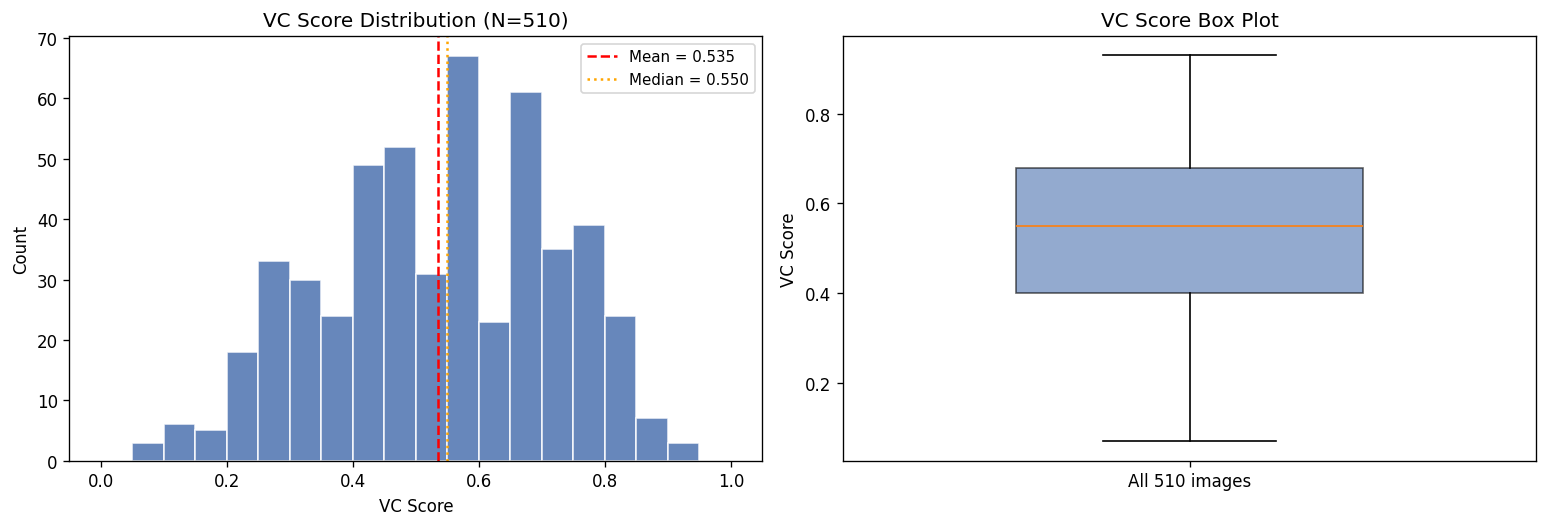

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram
ax = axes[0]
bins = np.arange(0, 1.05, 0.05)
ax.hist(df['vc_score'], bins=bins, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(df['vc_score'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {df["vc_score"].mean():.3f}')
ax.axvline(df['vc_score'].median(), color='orange', linestyle=':', linewidth=1.5,
           label=f'Median = {df["vc_score"].median():.3f}')
ax.set_xlabel('VC Score')
ax.set_ylabel('Count')
ax.set_title(f'VC Score Distribution (N={len(df)})')
ax.legend(fontsize=9)

# Box plot by quartile bands
ax = axes[1]
ax.boxplot(df['vc_score'], vert=True, widths=0.5,
           patch_artist=True, boxprops=dict(facecolor='#4C72B0', alpha=0.6))
ax.set_ylabel('VC Score')
ax.set_title('VC Score Box Plot')
ax.set_xticklabels([f'All {len(df)} images'])

fig.tight_layout()
fig.savefig('figures/vc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. VC Score by Visualization Type

In [37]:
# Per-VisType summary
vt = df.groupby('VisType')['vc_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
vt = vt.sort_values('mean', ascending=False)
print(vt.to_string(float_format='%.3f'))

                 count  mean  median   std   min   max
VisType                                               
Node-link           66 0.609   0.665 0.186 0.160 0.880
Grid                65 0.590   0.600 0.172 0.070 0.930
Glyph               64 0.574   0.620 0.191 0.080 0.870
Cont.-ColorPatn     42 0.555   0.580 0.168 0.100 0.820
Text                51 0.553   0.520 0.149 0.280 0.840
Area                65 0.539   0.550 0.178 0.150 0.920
Point               58 0.508   0.490 0.159 0.220 0.820
Line                48 0.427   0.410 0.163 0.080 0.790
Bar                 51 0.410   0.370 0.178 0.130 0.780


C:\Users\mling\AppData\Local\Temp\ipykernel_27732\3674715934.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_vt, labels=vt_order, patch_artist=True, vert=True, widths=0.6)


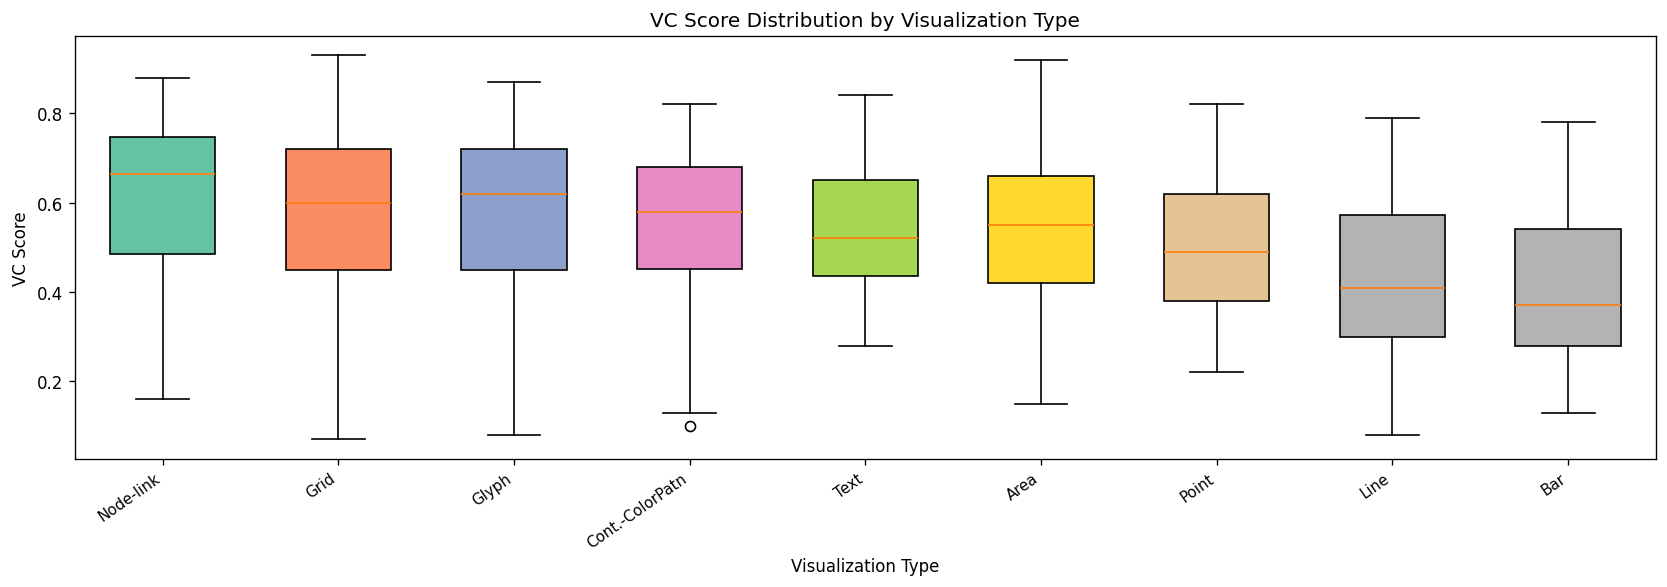

In [38]:
# Box plot by VisType
vt_order = vt.index.tolist()
data_by_vt = [df[df['VisType'] == vt_name]['vc_score'].values for vt_name in vt_order]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_by_vt, labels=vt_order, patch_artist=True, vert=True, widths=0.6)

colors = plt.cm.Set2(np.linspace(0, 1, len(vt_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Visualization Type')
ax.set_ylabel('VC Score')
ax.set_title('VC Score Distribution by Visualization Type')
plt.xticks(rotation=35, ha='right', fontsize=9)
fig.tight_layout()
fig.savefig('figures/vc_by_vistype.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Dimension-Level Analysis

In [39]:
dims = ['data_density', 'visual_encoding', 'text_annotation',
        'domain_schema', 'color_symbol', 'aesthetic_order', 'cognitive_load']
dim_labels = ['Data Density', 'Visual Encoding', 'Text Annotation',
              'Domain Schema', 'Color & Symbol', 'Aesthetic Order', 'Cognitive Load']

# Summary stats per dimension
dim_stats = df[dims].describe().T[['mean', 'std', 'min', 'max']]
dim_stats.index = dim_labels
print(dim_stats.to_string(float_format='%.3f'))

                 mean   std   min   max
Data Density    0.555 0.207 0.050 0.950
Visual Encoding 0.536 0.182 0.050 0.900
Text Annotation 0.386 0.266 0.000 0.980
Domain Schema   0.554 0.195 0.050 0.920
Color & Symbol  0.471 0.197 0.030 0.950
Aesthetic Order 0.488 0.210 0.050 0.950
Cognitive Load  0.558 0.198 0.050 0.950


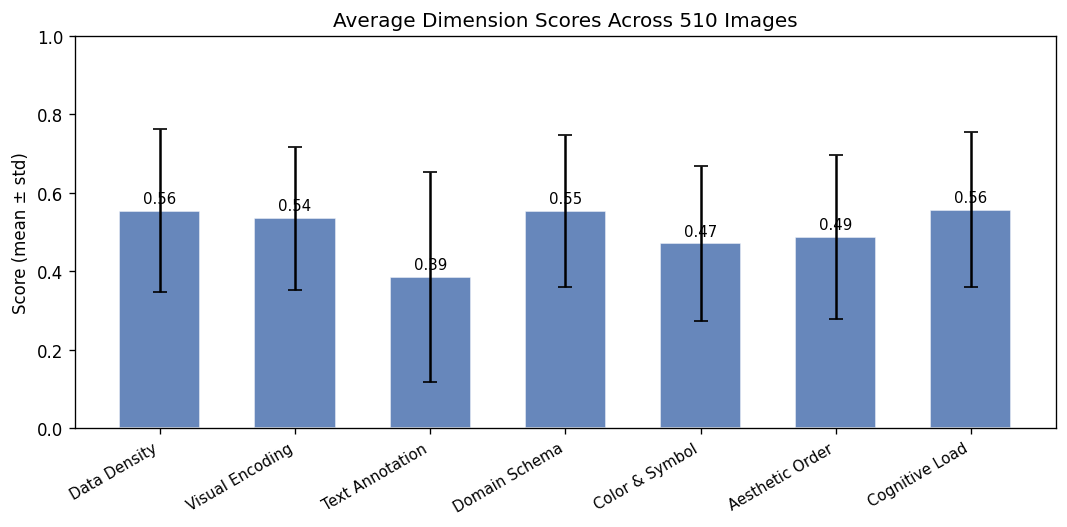

In [40]:
# Mean dimension scores bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(len(dims))
means = df[dims].mean()
stds = df[dims].std()

bars = ax.bar(x_pos, means, yerr=stds, width=0.6, color='#4C72B0',
              edgecolor='white', capsize=4, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score (mean ± std)')
ax.set_title(f'Average Dimension Scores Across {len(df)} Images')
ax.set_ylim(0, 1)

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{m:.2f}', ha='center', fontsize=9)

fig.tight_layout()
fig.savefig('figures/dimension_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

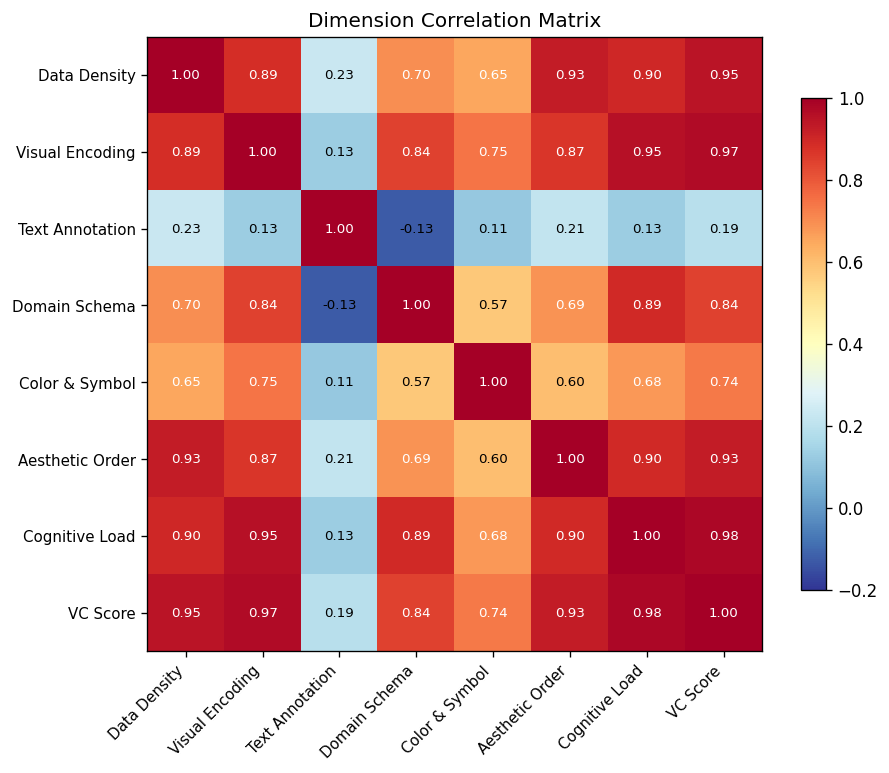

In [41]:
# Dimension correlation matrix
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[dims + ['vc_score']].corr()
corr.index = dim_labels + ['VC Score']
corr.columns = dim_labels + ['VC Score']

im = ax.imshow(corr, cmap='RdYlBu_r', vmin=-0.2, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.index, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

ax.set_title('Dimension Correlation Matrix')
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig('figures/dimension_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Dimension Profiles by VisType

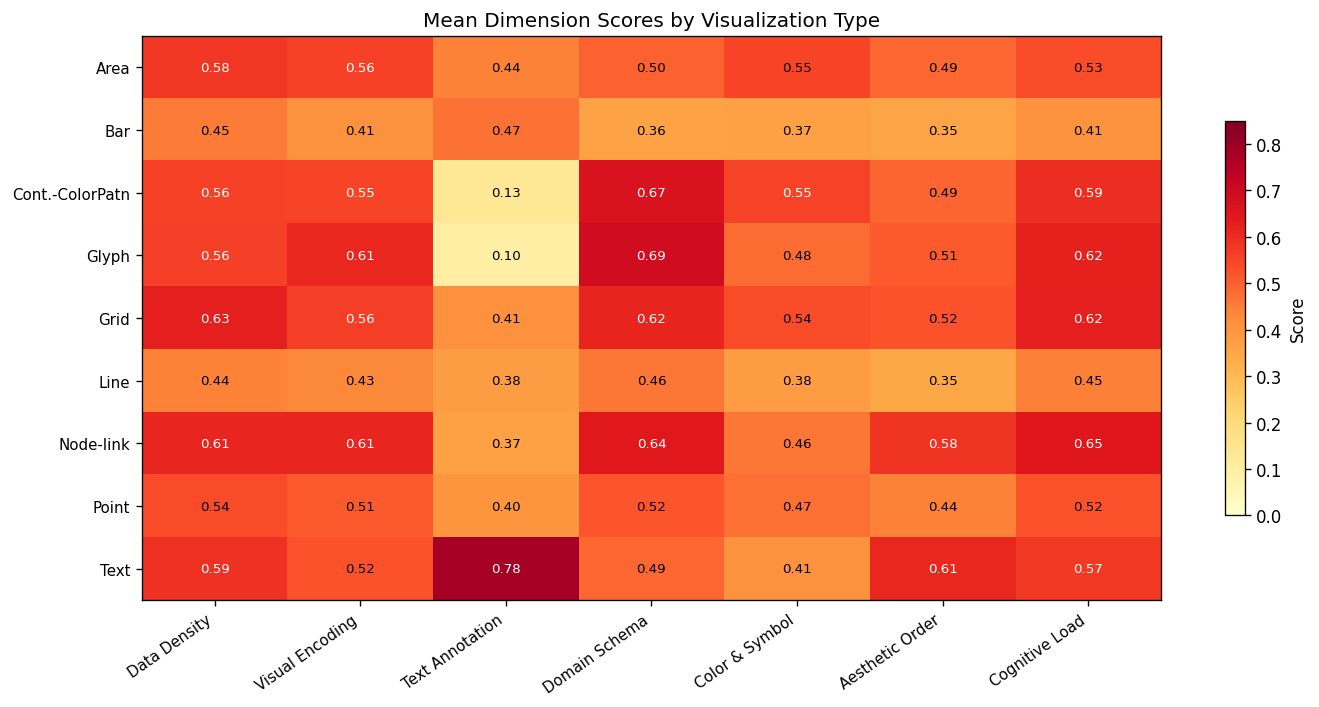

In [42]:
# Radar / heatmap of mean dimension scores per VisType
vt_dim = df.groupby('VisType')[dims].mean()
vt_dim.columns = dim_labels

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(vt_dim.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.85)

ax.set_xticks(range(len(dim_labels)))
ax.set_xticklabels(dim_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(vt_dim)))
ax.set_yticklabels(vt_dim.index, fontsize=9)

for i in range(vt_dim.shape[0]):
    for j in range(vt_dim.shape[1]):
        ax.text(j, i, f'{vt_dim.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if vt_dim.iloc[i, j] > 0.55 else 'black')

ax.set_title('Mean Dimension Scores by Visualization Type')
fig.colorbar(im, ax=ax, shrink=0.7, label='Score')
fig.tight_layout()
fig.savefig('figures/dimension_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ground Truth Calibration Check
The V3 prompt was developed using 3 anchor images (few-shot examples) and 46 calibration images.  
We report metrics separately for **seen** (anchors + calibration) vs **unseen** (purely predicted) images.

In [ ]:
# Load full GT from image_compiled_phrases.csv
gt_full = pd.read_csv('../phrase_reduction_v2/image_compiled_phrases.csv')
gt_full = gt_full[~gt_full['VisType'].isin(EXCLUDE_VT)]
df_gt = gt_full.merge(scores, left_on='imageName', right_on='filename', how='inner')
print(f'GT matched: {len(df_gt)} / {len(gt_full)} images')

# Define seen images: 46 calibration images from 23 pairs (includes 3 anchors)
ANCHOR_IMAGES = {'VisC.503.6.png', 'InfoVisJ.619.17.png', 'InfoVisJ.1149.6(1).png'}
pairs = pd.read_excel('image_pairs.xlsx')
SEEN_IMAGES = ANCHOR_IMAGES | set(pairs['image1']) | set(pairs['image2'])

df_gt['split'] = df_gt['imageName'].apply(lambda x: 'seen' if x in SEEN_IMAGES else 'unseen')
n_seen = (df_gt['split'] == 'seen').sum()
n_unseen = (df_gt['split'] == 'unseen').sum()
print(f'  Seen (anchors + calibration): {n_seen}')
print(f'  Unseen (purely predicted):     {n_unseen}')

# Compute metrics for each split
def _metrics(y_true, y_pred):
    r, _ = stats.pearsonr(y_true, y_pred)
    rho, _ = stats.spearmanr(y_true, y_pred)
    return {'Pearson r': r, 'Spearman ρ': rho, 'R²': r**2,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'Bias': np.mean(y_pred - y_true)}

rows = []
for label, mask in [('All', slice(None)),
                     (f'Seen', df_gt['split'] == 'seen'),
                     (f'Unseen', df_gt['split'] == 'unseen')]:
    sub = df_gt.loc[mask] if not isinstance(mask, slice) else df_gt
    m = _metrics(sub['NormalizedVC'].values, sub['vc_score'].values)
    m['Split'] = f'{label} (n={len(sub)})'
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index('Split')
print(f'\n{metrics_df.to_string(float_format="%.3f")}')

# Store for later use
gt_vc = df_gt['NormalizedVC'].values
pred_vc = df_gt['vc_score'].values
r = metrics_df.loc[metrics_df.index.str.startswith('Unseen'), 'Pearson r'].values[0]
rho = metrics_df.loc[metrics_df.index.str.startswith('Unseen'), 'Spearman ρ'].values[0]
mae = metrics_df.loc[metrics_df.index.str.startswith('Unseen'), 'MAE'].values[0]
bias = metrics_df.loc[metrics_df.index.str.startswith('Unseen'), 'Bias'].values[0]

GT matched: 510 / 510 images
  Seen (anchors + calibration): 46
  Unseen (purely predicted):     464

                      Pearson r  Spearman ρ    R²   MAE  RMSE   Bias
Split                                                               
All (n=510)               0.856       0.852 0.733 0.093 0.114 -0.063
Seen (49) (n=46)          0.912       0.907 0.831 0.074 0.089 -0.025
Unseen (461) (n=464)      0.851       0.847 0.723 0.095 0.116 -0.067


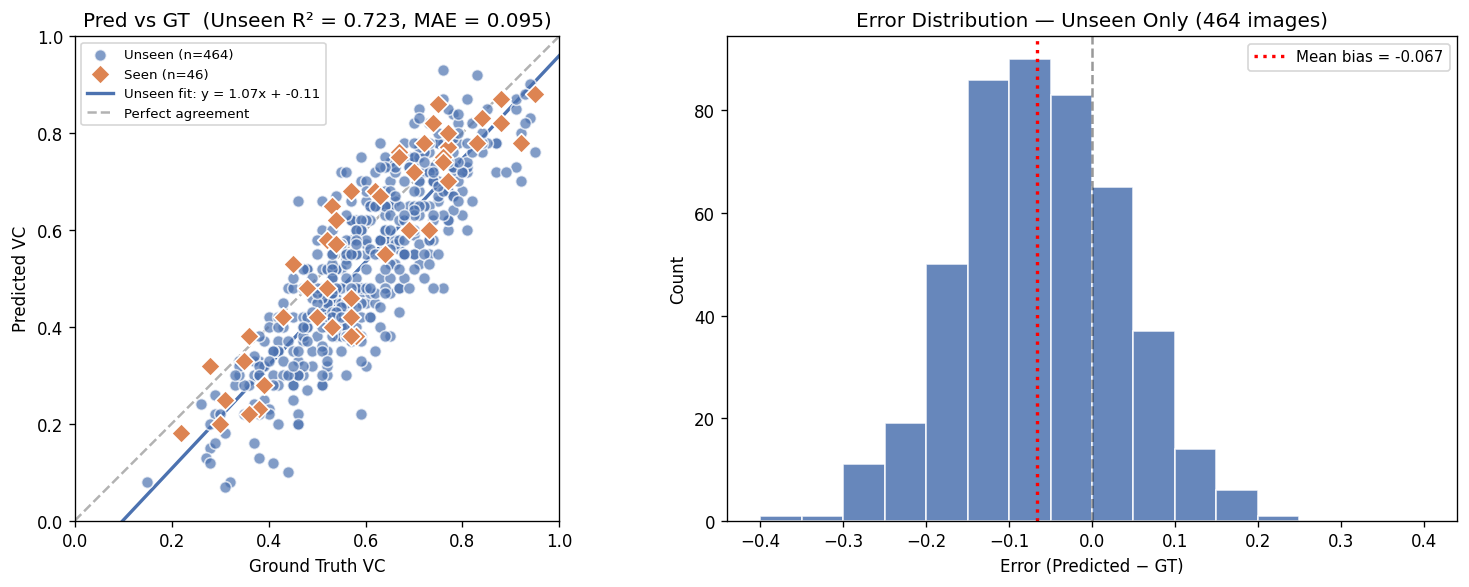

In [44]:
# Scatter: seen vs unseen, color-coded
df_seen = df_gt[df_gt['split'] == 'seen']
df_unseen = df_gt[df_gt['split'] == 'unseen']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter with seen/unseen colors
ax = axes[0]
ax.scatter(df_unseen['NormalizedVC'], df_unseen['vc_score'],
           c='#4C72B0', edgecolors='white', s=50, zorder=3, alpha=0.7, label=f'Unseen (n={len(df_unseen)})')
ax.scatter(df_seen['NormalizedVC'], df_seen['vc_score'],
           c='#DD8452', edgecolors='white', s=70, zorder=4, marker='D', label=f'Seen (n={len(df_seen)})')

# Regression on unseen only
slope_u, intercept_u, r_u, p_u, se_u = stats.linregress(df_unseen['NormalizedVC'], df_unseen['vc_score'])
x_fit = np.linspace(0, 1, 100)
ax.plot(x_fit, slope_u * x_fit + intercept_u, c='#4C72B0', linewidth=2,
        label=f'Unseen fit: y = {slope_u:.2f}x + {intercept_u:.2f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect agreement')
ax.set_xlabel('Ground Truth VC')
ax.set_ylabel('Predicted VC')
ax.set_title(f'Pred vs GT  (Unseen R² = {r_u**2:.3f}, MAE = {mae:.3f})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper left')

# Right: error distribution, unseen only
ax = axes[1]
errors_unseen = df_unseen['vc_score'].values - df_unseen['NormalizedVC'].values
ax.hist(errors_unseen, bins=np.arange(-0.4, 0.45, 0.05), color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.axvline(bias, color='red', linestyle=':', linewidth=2, label=f'Mean bias = {bias:+.3f}')
ax.set_xlabel('Error (Predicted − GT)')
ax.set_ylabel('Count')
ax.set_title(f'Error Distribution — Unseen Only ({len(df_unseen)} images)')
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig('figures/gt_scatter_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [45]:
print(f'=== {len(df)}-Image Production Run Summary ===')
print(f'Total images:        {len(df)}')
print(f'VC mean ± std:       {df["vc_score"].mean():.3f} ± {df["vc_score"].std():.3f}')
print(f'VC range:            [{df["vc_score"].min():.2f}, {df["vc_score"].max():.2f}]')
print(f'VisTypes:            {df["VisType"].nunique()}')
print()
print(f'GT calibration (unseen {len(df_unseen)} images):')
print(f'  Pearson r:         {r:.3f}')
print(f'  Spearman ρ:        {rho:.3f}')
print(f'  MAE:               {mae:.3f}')
print(f'  Bias:              {bias:+.3f}')
print()

# Top/bottom 5 images
print('Top 5 highest VC:')
for _, row in df.nlargest(5, 'vc_score').iterrows():
    print(f'  {row["filename"]:<45} vc={row["vc_score"]:.2f}  ({row["VisType"]})')
print('\nTop 5 lowest VC:')
for _, row in df.nsmallest(5, 'vc_score').iterrows():
    print(f'  {row["filename"]:<45} vc={row["vc_score"]:.2f}  ({row["VisType"]})')

=== 510-Image Production Run Summary ===
Total images:        510
VC mean ± std:       0.535 ± 0.183
VC range:            [0.07, 0.93]
VisTypes:            9

GT calibration (unseen 464 images):
  Pearson r:         0.851
  Spearman ρ:        0.847
  MAE:               0.095
  Bias:              -0.067

Top 5 highest VC:
  InfoVisJ.1149.8(2).png                        vc=0.93  (Grid)
  InfoVisJ.2402.12.png                          vc=0.92  (Area)
  InfoVisC.24.8(1).png                          vc=0.90  (Area)
  InfoVisJ.1149.6(1).png                        vc=0.88  (Grid)
  vis567.png                                    vc=0.88  (Node-link)

Top 5 lowest VC:
  VisC.297.4.png                                vc=0.07  (Grid)
  VisJ.1431.7.png                               vc=0.08  (Line)
  SciVisJ.980.9.png                             vc=0.08  (Glyph)
  SciVisJ.1043.12(4).png                        vc=0.10  (Cont.-ColorPatn)
  VASTC.81.3(2).png                             vc=0.12  (Glyph)
